# Handwritten Digit Recognition

A computer vision project that recognizes handwritten digits (0-9) using the scikit-learn `digits` dataset (1,797 images, 8x8 pixels each) and compares four ML classifiers: Logistic Regression, SVM, Random Forest, and a Neural Network (MLP).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib

%matplotlib inline

## 1. Load and visualize the data

In [2]:
digits = load_digits()
X, y = digits.data, digits.target
print(f"Dataset: {X.shape[0]} images, {X.shape[1]} pixel features each (8x8)")
print(f"Classes: {sorted(set(y))}")

Dataset: 1797 images, 64 pixel features each (8x8)
Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]


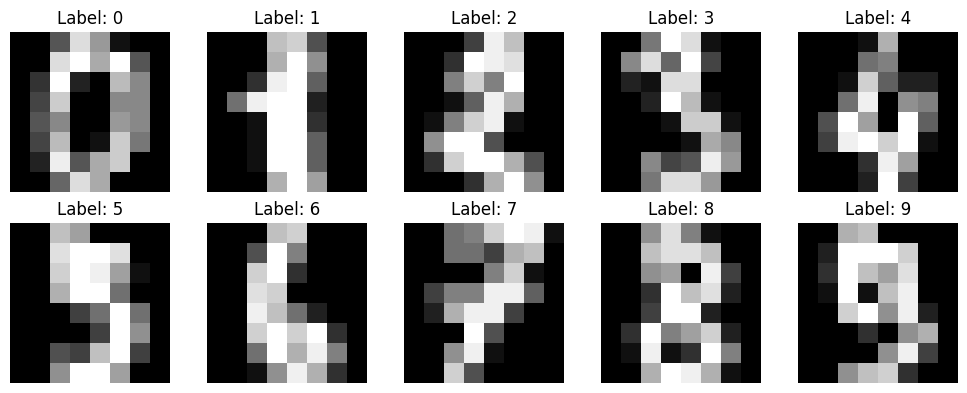

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, image, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 2. Train / test split and scaling

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Train: {X_train.shape[0]} samples, Test: {X_test.shape[0]} samples")

Train: 1437 samples, Test: 360 samples


## 3. Train and compare models

In [5]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Support Vector Machine": SVC(kernel="rbf", gamma="scale"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42),
}

results = {}
best_model_name, best_model, best_acc = None, None, 0.0

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    results[name] = acc
    print(f"\n=== {name} (accuracy: {acc:.4f}) ===")
    print(classification_report(y_test, preds))
    if acc > best_acc:
        best_acc, best_model_name, best_model = acc, name, model

print(f"Best model: {best_model_name} ({best_acc:.4f})")


=== Logistic Regression (accuracy: 0.9722) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.89      0.89      0.89        36
           2       1.00      1.00      1.00        35
           3       0.97      1.00      0.99        37
           4       0.97      1.00      0.99        36
           5       1.00      1.00      1.00        37
           6       1.00      0.97      0.99        36
           7       1.00      1.00      1.00        36
           8       0.89      0.89      0.89        35
           9       1.00      0.97      0.99        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360


=== Support Vector Machine (accuracy: 0.9750) ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        36
           1       0.95      0.97


=== Random Forest (accuracy: 0.9639) ===
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        36
           1       0.92      0.97      0.95        36
           2       1.00      0.97      0.99        35
           3       0.97      0.97      0.97        37
           4       0.97      1.00      0.99        36
           5       0.97      1.00      0.99        37
           6       1.00      0.97      0.99        36
           7       0.92      1.00      0.96        36
           8       0.94      0.86      0.90        35
           9       0.97      0.92      0.94        36

    accuracy                           0.96       360
   macro avg       0.96      0.96      0.96       360
weighted avg       0.96      0.96      0.96       360




=== Neural Network (MLP) (accuracy: 0.9667) ===
              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      0.92      0.92        36
           2       0.95      1.00      0.97        35
           3       0.97      0.97      0.97        37
           4       0.95      1.00      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.94      0.97        36
           7       0.97      1.00      0.99        36
           8       0.94      0.91      0.93        35
           9       1.00      0.94      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360

Best model: Support Vector Machine (0.9750)


## 4. Model comparison chart

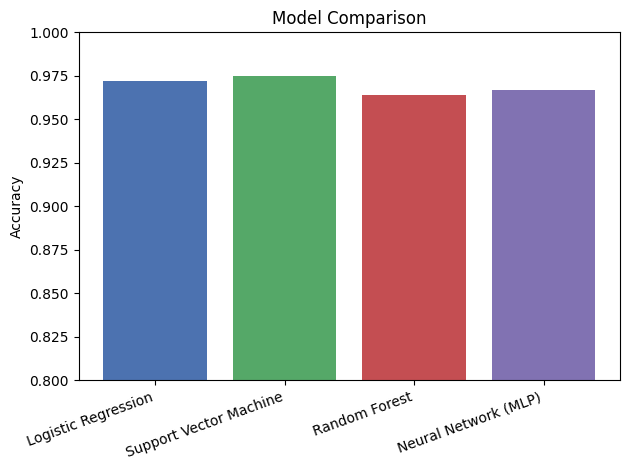

In [6]:
plt.bar(results.keys(), results.values(), color=["#4C72B0", "#55A868", "#C44E52", "#8172B2"])
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.ylim(0.8, 1.0)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 5. Confusion matrix for the best model

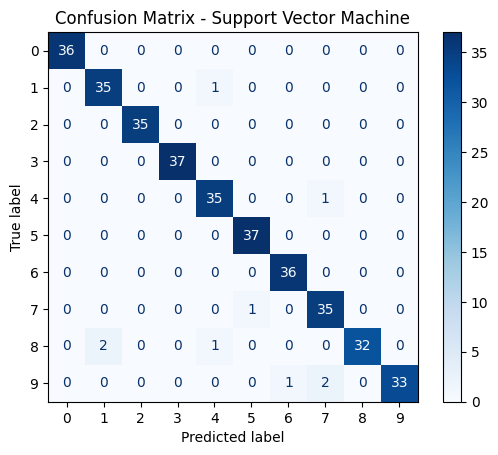

In [7]:
preds = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

## 6. Inspect misclassified digits

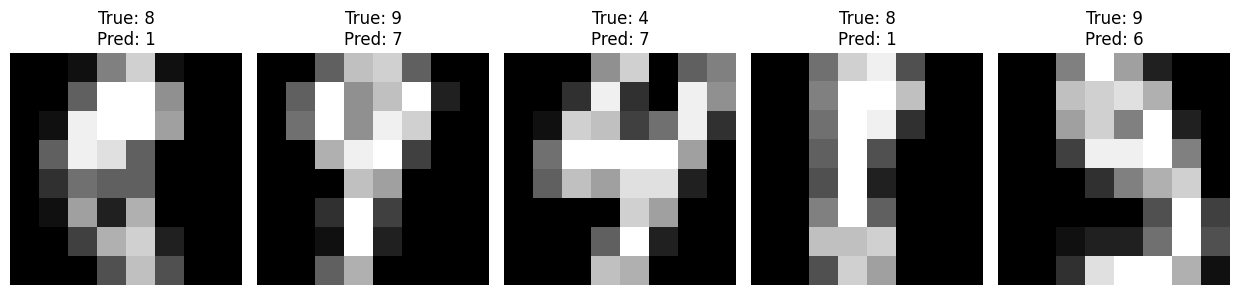

In [8]:
misclassified_idx = np.where(preds != y_test)[0]
n_show = min(5, len(misclassified_idx))
fig, axes = plt.subplots(1, n_show, figsize=(2.5 * n_show, 3))
if n_show == 1:
    axes = [axes]
for ax, idx in zip(axes, misclassified_idx[:n_show]):
    image = X_test[idx].reshape(8, 8)
    ax.imshow(image, cmap="gray")
    ax.set_title(f"True: {y_test[idx]}\nPred: {preds[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Save the model

In [9]:
joblib.dump(best_model, "digit_model.joblib")
joblib.dump(scaler, "scaler.joblib")
print("Model and scaler saved.")

Model and scaler saved.
